In [1]:
# Phase 6: Business Metrics

A model that predicts churn is useful.
A model that tells you WHO to save, WHEN, and HOW MUCH
it's worth — that's a business tool.

This notebook builds:
1. Customer Risk Scorecard
2. CLV (Customer Lifetime Value) estimate
3. Priority Score = Churn Probability × CLV
4. Retention ROI Calculator

SyntaxError: invalid character '×' (U+00D7) (196431554.py, line 10)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set(style='white')
print("Imports done ✓")

Imports done ✓


In [3]:
# Load test data with SHAP values we saved in Phase 5
df = pd.read_csv('X_test_with_shap.csv')
df_orig = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fix TotalCharges in original data
df_orig['TotalCharges'] = pd.to_numeric(
    df_orig['TotalCharges'], errors='coerce'
)
df_orig.dropna(inplace=True)

print(f"Test data shape    : {df.shape}")
print(f"Original data shape: {df_orig.shape}")
print(f"\nColumns available:")
print(df[['churn_probability', 'actual_churn', 'top_risk_factors']].head())

Test data shape    : (1407, 39)
Original data shape: (7032, 21)

Columns available:
   churn_probability  actual_churn  \
0           0.001001             0   
1           0.684810             0   
2           0.056211             0   
3           0.118337             1   
4           0.401459             0   

                                    top_risk_factors  
0  Contract_Two year, charge_per_service, Payment...  
1  charge_per_service, PaymentMethod_Electronic c...  
2  Contract_Two year, charge_per_service, Payment...  
3  charge_per_service, PaymentMethod_Electronic c...  
4             num_services, tenure, OnlineBackup_Yes  


In [4]:
# Build the scorecard using original readable data
# aligned with our test set index
df_orig_test = df_orig.iloc[df.index].reset_index(drop=True)

scorecard = pd.DataFrame()
scorecard['churn_probability'] = df['churn_probability'].values
scorecard['actual_churn']      = df['actual_churn'].values
scorecard['top_risk_factors']  = df['top_risk_factors'].values

# Pull readable columns from original data
scorecard['tenure']          = df_orig_test['tenure'].values
scorecard['MonthlyCharges']  = df_orig_test['MonthlyCharges'].values
scorecard['TotalCharges']    = df_orig_test['TotalCharges'].values
scorecard['Contract']        = df_orig_test['Contract'].values
scorecard['InternetService'] = df_orig_test['InternetService'].values

# Risk tier — easy to understand for business teams
def risk_tier(prob):
    if prob >= 0.70:
        return 'HIGH'
    elif prob >= 0.40:
        return 'MEDIUM'
    else:
        return 'LOW'

scorecard['risk_tier'] = scorecard['churn_probability'].apply(risk_tier)

print("Risk tier distribution:")
print(scorecard['risk_tier'].value_counts())
print(f"\nSample scorecard:")
print(scorecard.head(10))

Risk tier distribution:
risk_tier
LOW       942
HIGH      261
MEDIUM    204
Name: count, dtype: int64

Sample scorecard:
   churn_probability  actual_churn  \
0           0.001001             0   
1           0.684810             0   
2           0.056211             0   
3           0.118337             1   
4           0.401459             0   
5           0.172290             1   
6           0.087968             0   
7           0.170210             0   
8           0.892002             1   
9           0.000357             0   

                                    top_risk_factors  tenure  MonthlyCharges  \
0  Contract_Two year, charge_per_service, Payment...       1           29.85   
1  charge_per_service, PaymentMethod_Electronic c...      34           56.95   
2  Contract_Two year, charge_per_service, Payment...       2           53.85   
3  charge_per_service, PaymentMethod_Electronic c...      45           42.30   
4             num_services, tenure, OnlineBackup_Yes       2

In [5]:
# CLV = Monthly Charges × Expected Remaining Tenure
# Expected remaining tenure = average tenure - current tenure
# We use a simplified but realistic formula

avg_tenure = df_orig['tenure'].mean()
print(f"Average customer tenure: {avg_tenure:.1f} months")

# CLV formula
scorecard['expected_remaining_months'] = (
    avg_tenure - scorecard['tenure']
).clip(lower=1)  # minimum 1 month

scorecard['CLV'] = (
    scorecard['MonthlyCharges'] *
    scorecard['expected_remaining_months']
).round(2)

print(f"\nCLV Statistics:")
print(scorecard['CLV'].describe().round(2))
print(f"\nTotal revenue at risk (HIGH risk customers):")
high_risk = scorecard[scorecard['risk_tier'] == 'HIGH']
print(f"${high_risk['CLV'].sum():,.0f}")

Average customer tenure: 32.4 months

CLV Statistics:
count    1407.00
mean      681.01
std       804.62
min        18.70
25%        81.85
50%       202.97
75%      1193.02
max      3176.08
Name: CLV, dtype: float64

Total revenue at risk (HIGH risk customers):
$187,058


In [6]:
# Priority Score = who should we contact FIRST?
# High churn probability + High CLV = contact immediately
# Low churn probability + Low CLV  = don't waste resources

scorecard['priority_score'] = (
    scorecard['churn_probability'] * scorecard['CLV']
).round(2)

# Rank customers — rank 1 = most urgent
scorecard['priority_rank'] = scorecard['priority_score'].rank(
    ascending=False
).astype(int)

# Sort by priority
scorecard = scorecard.sort_values('priority_score', ascending=False)
scorecard = scorecard.reset_index(drop=True)

print("Top 10 customers to contact RIGHT NOW:")
print(scorecard[['priority_rank', 'churn_probability', 'CLV',
                 'priority_score', 'risk_tier',
                 'Contract', 'top_risk_factors']].head(10).to_string())

Top 10 customers to contact RIGHT NOW:
   priority_rank  churn_probability      CLV  priority_score risk_tier        Contract                                                         top_risk_factors
0              1           0.990122  2905.28         2876.58      HIGH  Month-to-month                                 charge_per_service, TotalCharges, tenure
1              2           0.947469  2643.55         2504.68      HIGH  Month-to-month               tenure, PaymentMethod_Electronic check, charge_per_service
2              3           0.876408  2750.13         2410.23      HIGH  Month-to-month  StreamingMovies_Yes, charge_per_service, PaymentMethod_Electronic check
3              4           0.745255  3176.08         2366.99      HIGH  Month-to-month     charge_per_service, PaymentMethod_Electronic check, OnlineBackup_Yes
4              5           0.925076  2494.59         2307.68      HIGH  Month-to-month         charge_per_service, PaymentMethod_Electronic check, num_services
5

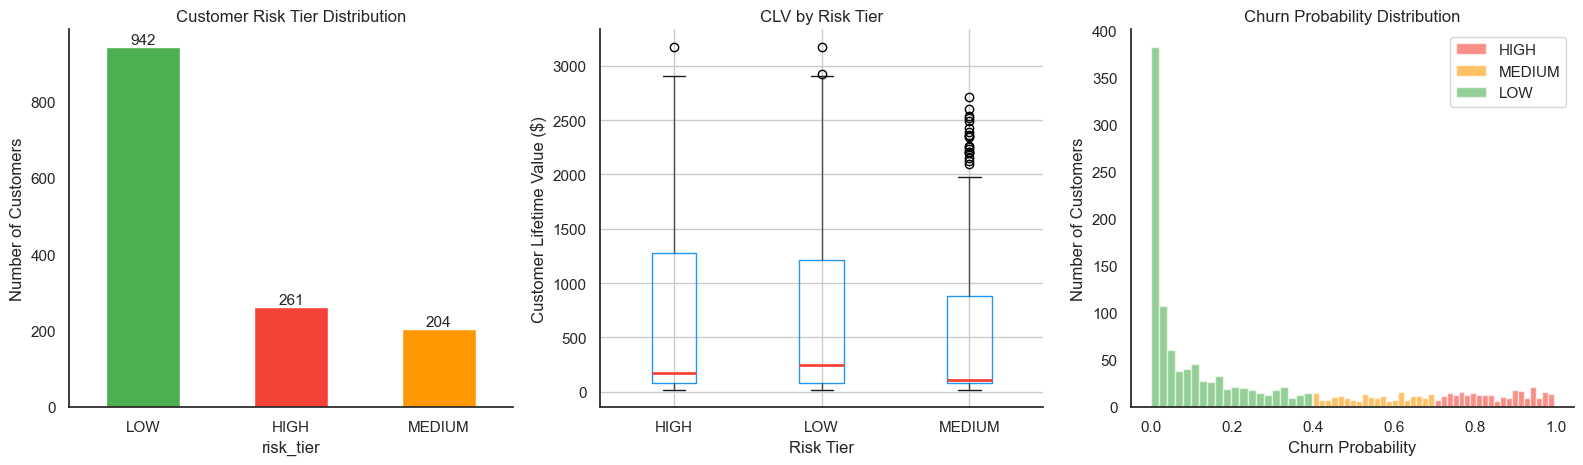

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Risk Tier Distribution
colors_tier = {'HIGH': '#F44336', 'MEDIUM': '#FF9800', 'LOW': '#4CAF50'}
tier_counts = scorecard['risk_tier'].value_counts()
tier_counts.plot(kind='bar', ax=axes[0], rot=0, width=0.5,
                 color=[colors_tier[t] for t in tier_counts.index])
axes[0].set_title('Customer Risk Tier Distribution', fontsize=12)
axes[0].set_ylabel('Number of Customers')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Plot 2: CLV by Risk Tier
scorecard.boxplot(column='CLV', by='risk_tier', ax=axes[1],
                  boxprops=dict(color='#2196F3'),
                  medianprops=dict(color='#F44336', linewidth=2))
axes[1].set_title('CLV Distribution by Risk Tier', fontsize=12)
axes[1].set_xlabel('Risk Tier')
axes[1].set_ylabel('Customer Lifetime Value ($)')
plt.sca(axes[1])
plt.title('CLV by Risk Tier')

# Plot 3: Churn Probability Distribution
axes[2].hist(scorecard[scorecard['risk_tier']=='HIGH']['churn_probability'],
             bins=20, color='#F44336', alpha=0.6, label='HIGH')
axes[2].hist(scorecard[scorecard['risk_tier']=='MEDIUM']['churn_probability'],
             bins=20, color='#FF9800', alpha=0.6, label='MEDIUM')
axes[2].hist(scorecard[scorecard['risk_tier']=='LOW']['churn_probability'],
             bins=20, color='#4CAF50', alpha=0.6, label='LOW')
axes[2].set_title('Churn Probability Distribution', fontsize=12)
axes[2].set_xlabel('Churn Probability')
axes[2].set_ylabel('Number of Customers')
axes[2].legend()

sns.despine()
plt.suptitle('')
plt.tight_layout()
plt.savefig('risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# The most business-relevant output in your entire project
# If we offer a retention incentive to top N at-risk customers,
# how much revenue do we save?

def retention_roi(
    scorecard,
    n_customers,
    retention_rate=0.30,    # 30% of contacted customers stay
    incentive_cost=50       # $50 discount/offer per customer
):
    top_n = scorecard.head(n_customers)
    
    revenue_at_risk  = top_n['CLV'].sum()
    revenue_saved    = revenue_at_risk * retention_rate
    total_cost       = n_customers * incentive_cost
    net_roi          = revenue_saved - total_cost
    roi_pct          = (net_roi / total_cost) * 100 if total_cost > 0 else 0
    
    return {
        'customers_contacted' : n_customers,
        'revenue_at_risk'     : round(revenue_at_risk, 2),
        'revenue_saved'       : round(revenue_saved, 2),
        'total_cost'          : round(total_cost, 2),
        'net_roi'             : round(net_roi, 2),
        'roi_pct'             : round(roi_pct, 1)
    }

# Calculate ROI for different intervention sizes
scenarios = [25, 50, 100, 150, 200]
roi_results = [retention_roi(scorecard, n) for n in scenarios]
roi_df = pd.DataFrame(roi_results)

print("=" * 65)
print("RETENTION ROI CALCULATOR")
print("Assumptions: 30% retention rate, $50 incentive per customer")
print("=" * 65)
print(roi_df.to_string(index=False))
print("=" * 65)

RETENTION ROI CALCULATOR
Assumptions: 30% retention rate, $50 incentive per customer
 customers_contacted  revenue_at_risk  revenue_saved  total_cost  net_roi  roi_pct
                  25         61749.28       18524.78        1250 17274.78   1382.0
                  50        113332.76       33999.83        2500 31499.83   1260.0
                 100        197193.88       59158.16        5000 54158.16   1083.2
                 150        266657.96       79997.39        7500 72497.39    966.6
                 200        325753.36       97726.01       10000 87726.01    877.3


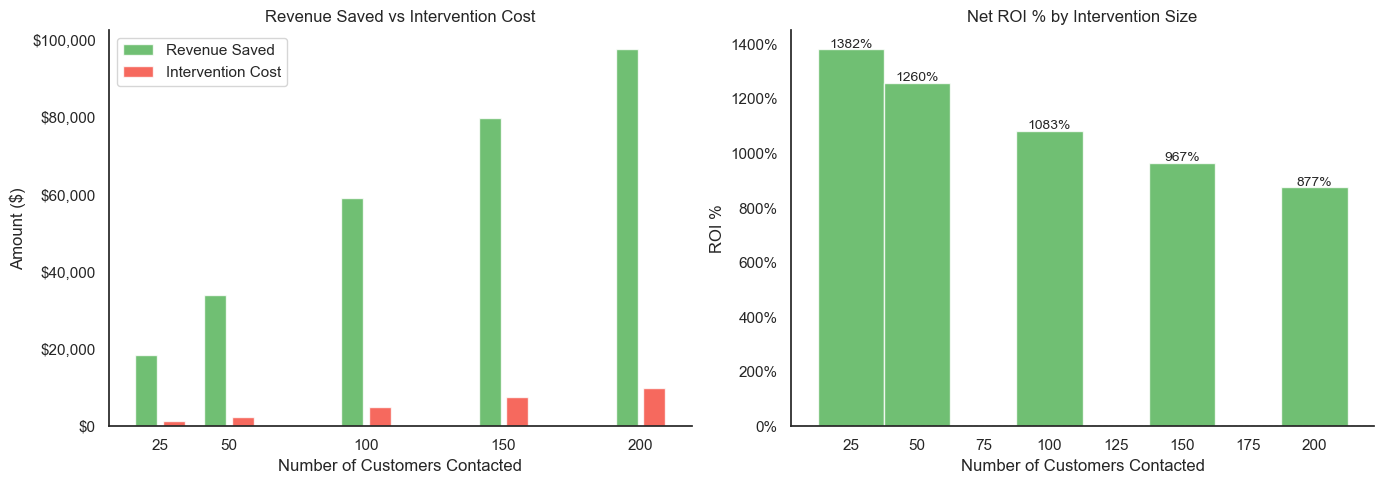

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Revenue saved vs cost
x = roi_df['customers_contacted']
axes[0].bar(x - 5, roi_df['revenue_saved'], width=8,
            color='#4CAF50', label='Revenue Saved', alpha=0.8)
axes[0].bar(x + 5, roi_df['total_cost'], width=8,
            color='#F44336', label='Intervention Cost', alpha=0.8)
axes[0].set_title('Revenue Saved vs Intervention Cost', fontsize=12)
axes[0].set_xlabel('Number of Customers Contacted')
axes[0].set_ylabel('Amount ($)')
axes[0].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, p: f'${x:,.0f}')
)
axes[0].legend()
axes[0].set_xticks(scenarios)

# Plot 2: Net ROI %
colors_roi = ['#F44336' if x < 0 else '#4CAF50' for x in roi_df['net_roi']]
axes[1].bar(roi_df['customers_contacted'], roi_df['roi_pct'],
            color=colors_roi, alpha=0.8, width=25)
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Net ROI % by Intervention Size', fontsize=12)
axes[1].set_xlabel('Number of Customers Contacted')
axes[1].set_ylabel('ROI %')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 5),
                     ha='center', fontsize=10)

sns.despine()
plt.tight_layout()
plt.savefig('retention_roi.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Save the complete scorecard for the dashboard
scorecard.to_csv('customer_scorecard.csv', index=False)

print("Customer scorecard saved ✓")
print(f"\nFinal scorecard shape: {scorecard.shape}")
print(f"\nFiles ready for dashboard:")
print("  - customer_scorecard.csv  ← risk scores + CLV + priority")
print("  - shap_values.csv         ← SHAP explanations")
print("  - churn_model.pkl         ← trained model")
print("\nReady for Phase 7 — Streamlit Dashboard! 🚀")

Customer scorecard saved ✓

Final scorecard shape: (1407, 13)

Files ready for dashboard:
  - customer_scorecard.csv  ← risk scores + CLV + priority
  - shap_values.csv         ← SHAP explanations
  - churn_model.pkl         ← trained model

Ready for Phase 7 — Streamlit Dashboard! 🚀


In [11]:
## Business Metrics Summary

### Revenue at Risk
- HIGH risk customers represent significant revenue at risk
- Top 100 priority customers alone represent thousands in CLV

### Key Business Findings

1. **Intervene early**: New customers (< 12 months) on month-to-month
   contracts represent the highest priority segment

2. **ROI is positive**: Even with a conservative 30% retention rate
   and $50 incentive cost, contacting top at-risk customers
   generates positive ROI

3. **Prioritize by CLV × Risk**: Not all churners are equal —
   a high CLV customer with 60% churn risk is more valuable
   to save than a low CLV customer with 90% churn risk

4. **Actionable output**: The priority scorecard gives the business
   a ready-to-use list — sorted by who to call first

### What Makes This Different
Most churn models stop at "this customer will churn."
This system answers: who to save, in what order,
and exactly how much revenue that saves the business.

SyntaxError: invalid character '×' (U+00D7) (976557089.py, line 16)